# Lab 2 — Resultados del Sketch-RNN VAE (train_v2)

Checkpoint afinado: `free_bits=0.05`, β: 0→0.2, 50 épocas.

Incluye generación, reconstrucciones (greedy), sketch completion con varias z, y curvas.


In [1]:
from __future__ import annotations

import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image, display

ROOT = Path("..").resolve() if (Path("..") / "outputs").exists() else Path(".").resolve()
sys.path.insert(0, str(ROOT))

from sketchvae.data import denormalize_stroke5
from sketchvae.dataset import load_stroke5_cache
from sketchvae.device import get_device
from sketchvae.model import SketchRNN, SketchRNNConfig, complete, generate, reconstruct
from sketchvae.viz import draw_stroke5

CKPT = ROOT / "outputs" / "train_v2" / "best.pt"
if not CKPT.exists():
    CKPT = ROOT / "outputs" / "train_v2" / "last.pt"
EVAL = ROOT / "outputs" / "eval_v2"
CACHE = ROOT / "outputs" / "preprocessed" / "stroke5.npz"

device = get_device("auto")
print("ROOT", ROOT)
print("device", device)
print("ckpt", CKPT, "exists", CKPT.exists())


ROOT /Users/luis.jauregui/Clases/GM/Lab2
device mps
ckpt /Users/luis.jauregui/Clases/GM/Lab2/outputs/train_v2/best.pt exists True


In [2]:
def load_model(ckpt_path: Path, device: torch.device):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg = SketchRNNConfig(**ckpt["cfg"])
    model = SketchRNN(cfg).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model, float(ckpt["scale"]), int(ckpt.get("max_len", 250)), ckpt


def to_abs(seq, scale: float) -> np.ndarray:
    arr = seq.detach().cpu().numpy() if torch.is_tensor(seq) else np.asarray(seq, dtype=np.float32)
    eos = np.where(arr[:, 4] > 0.5)[0]
    if len(eos):
        arr = arr[: eos[0] + 1]
    return denormalize_stroke5(arr.astype(np.float32), scale)


assert CKPT.exists(), f"No hay checkpoint en {CKPT}"
model, scale, max_len, ckpt = load_model(CKPT, device)
train_arr, val_arr, _, _ = load_stroke5_cache(CACHE)
print(f"epoch={ckpt.get('epoch')}  val_recon={ckpt.get('val_recon')}  scale={scale:.4f}")
print("cfg:", ckpt["cfg"])


epoch=49  val_recon=0.29299757635954654  scale=50.8887
cfg: {'enc_hidden': 256, 'dec_hidden': 512, 'z_size': 64, 'n_mixtures': 20, 'dropout': 0.0}


## 1. Curvas de entrenamiento


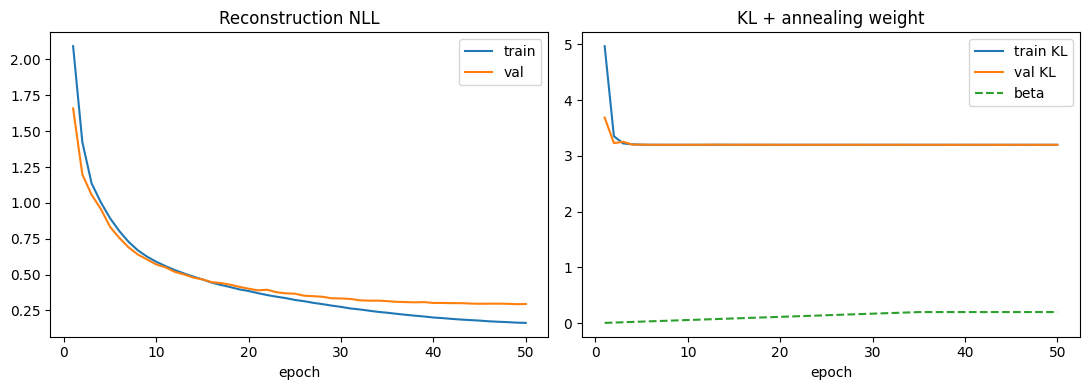

mejor val_recon=0.293 (epoch 49)


In [3]:
log_csv = CKPT.parent / "train_log.csv"
rows = list(csv.DictReader(log_csv.open()))
epochs = [int(r["epoch"]) for r in rows]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, [float(r["train_recon"]) for r in rows], label="train")
axes[0].plot(epochs, [float(r["val_recon"]) for r in rows], label="val")
axes[0].set_title("Reconstruction NLL")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(epochs, [float(r["train_kl"]) for r in rows], label="train KL")
axes[1].plot(epochs, [float(r["val_kl"]) for r in rows], label="val KL")
axes[1].plot(epochs, [float(r["kl_weight"]) for r in rows], label="beta", ls="--")
axes[1].set_title("KL + annealing weight")
axes[1].set_xlabel("epoch")
axes[1].legend()
fig.tight_layout()
plt.show()

best = min(rows, key=lambda r: float(r["val_recon"]))
print(f"mejor val_recon={float(best['val_recon']):.3f} (epoch {best['epoch']})")


## 2. Generación incondicional


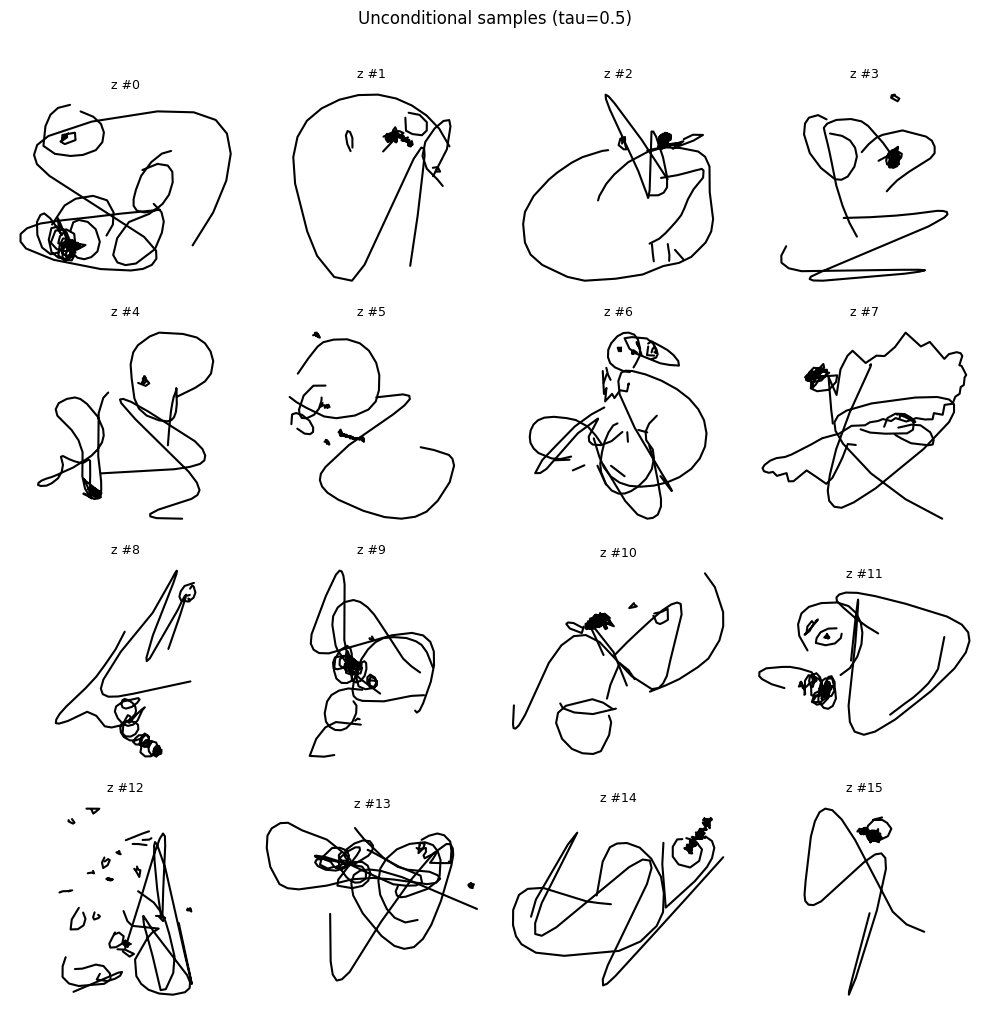

In [4]:
TEMP = 0.5
torch.manual_seed(0)
samples = generate(model, n=16, max_len=min(200, max_len), temperature=TEMP, device=device)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, i in zip(axes.ravel(), range(16)):
    draw_stroke5(to_abs(samples[i], scale), ax=ax, title=f"z #{i}")
fig.suptitle(f"Unconditional samples (tau={TEMP})", y=1.01)
fig.tight_layout()
plt.show()


## 3. Reconstrucciones (encode μ → greedy decode)


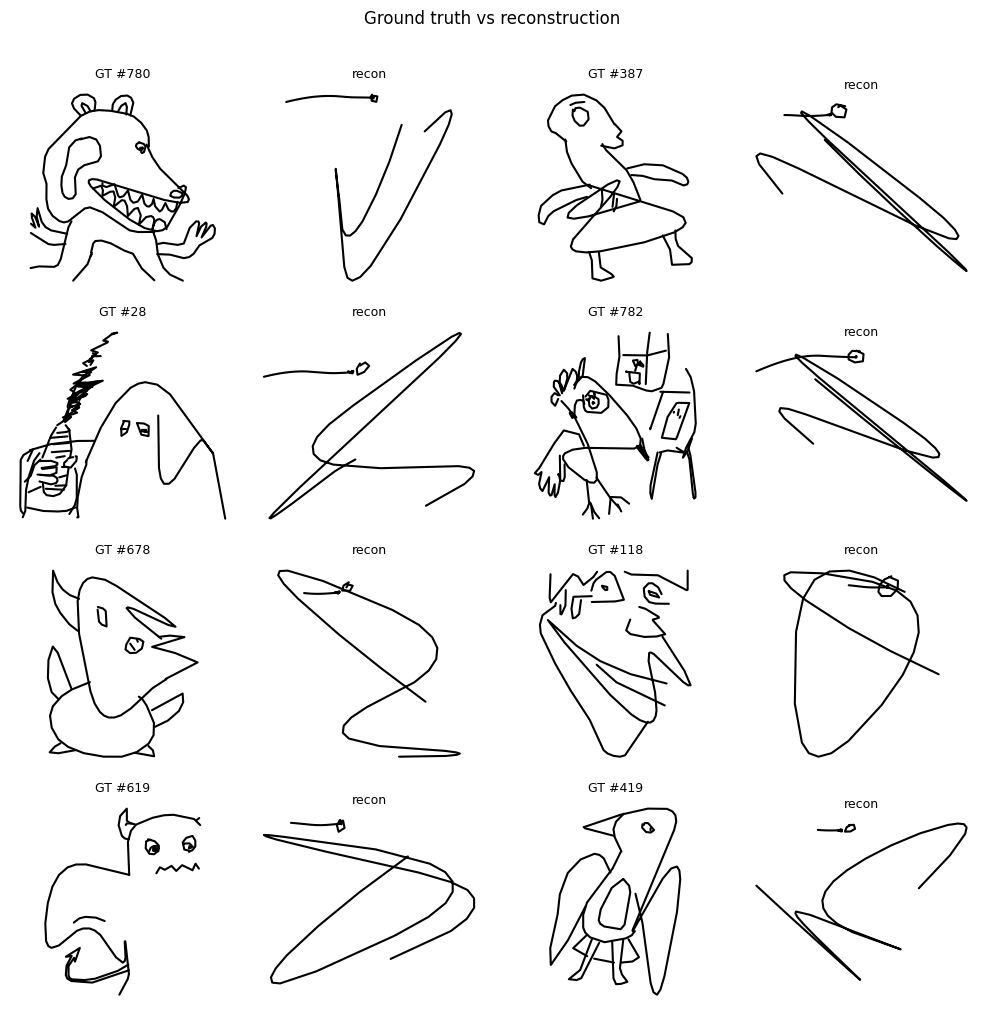

In [5]:
rng = np.random.default_rng(1)
idxs = rng.choice(len(val_arr), size=8, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, idx in enumerate(idxs):
    seq = torch.from_numpy(np.asarray(val_arr[idx], dtype=np.float32))
    recon = reconstruct(model, seq, device=device, greedy=True, use_mean_z=True)
    r, c = divmod(i, 2)
    draw_stroke5(to_abs(seq, scale), ax=axes[r, c * 2], title=f"GT #{idx}")
    draw_stroke5(to_abs(recon, scale), ax=axes[r, c * 2 + 1], title="recon")
fig.suptitle("Ground truth vs reconstruction", y=1.01)
fig.tight_layout()
plt.show()


## 4. Sketch completion — mismo prefijo, distintas z

z se muestrea de q(z|prefijo) para condicionar mejor la continuación.


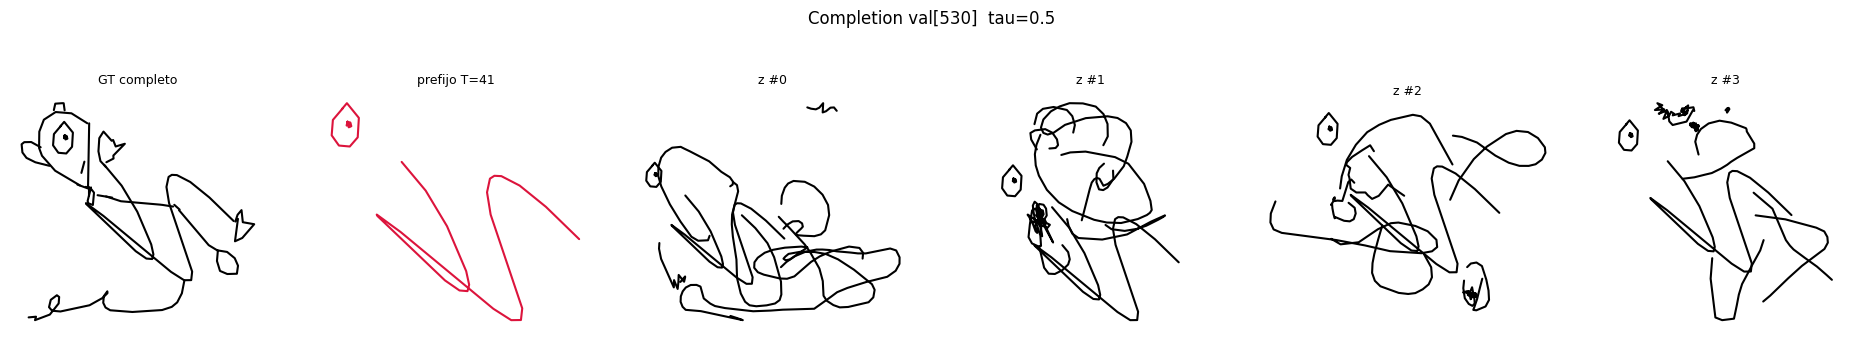

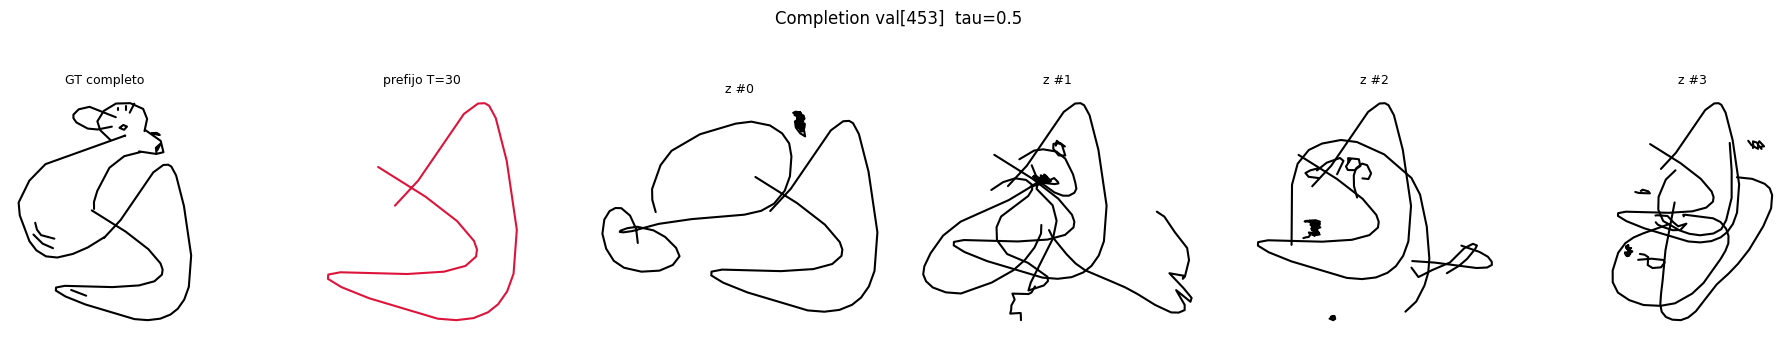

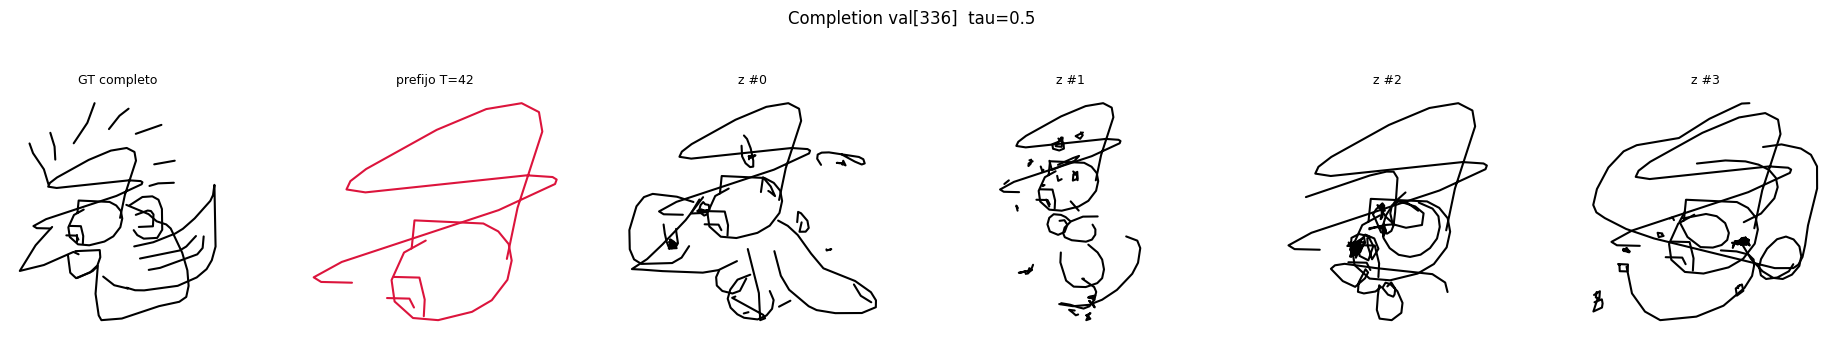

In [6]:
def make_prefix(seq: np.ndarray, frac: float = 0.33):
    n = max(5, int(len(seq) * frac))
    lifts = np.where(seq[:n, 3] > 0.5)[0]
    if len(lifts):
        n = int(lifts[-1]) + 1
    return seq[:n], n


def show_completion(idx: int, n_samples: int = 4, temperature: float = 0.5):
    full = np.asarray(val_arr[idx], dtype=np.float32)
    prefix, n_pref = make_prefix(full)
    comps = complete(
        model,
        torch.from_numpy(prefix),
        n_samples=n_samples,
        max_len=min(max_len, len(full) + 80),
        temperature=temperature,
        device=device,
        from_prefix_posterior=True,
    )
    fig, axes = plt.subplots(1, n_samples + 2, figsize=(3.2 * (n_samples + 2), 3.2))
    draw_stroke5(to_abs(full, scale), ax=axes[0], title="GT completo")
    draw_stroke5(to_abs(prefix, scale), ax=axes[1], title=f"prefijo T={n_pref}", color="crimson")
    for i in range(n_samples):
        draw_stroke5(to_abs(comps[i], scale), ax=axes[i + 2], title=f"z #{i}")
    fig.suptitle(f"Completion val[{idx}]  tau={temperature}", y=1.05)
    fig.tight_layout()
    plt.show()


for idx in rng.choice(len(val_arr), size=3, replace=False):
    show_completion(int(idx))


## 5. Comparación de temperaturas (misma z)


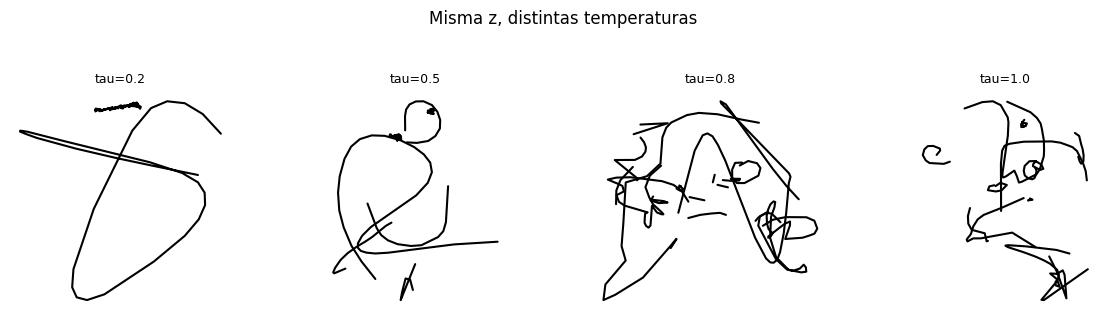

In [7]:
z = torch.randn(1, model.cfg.z_size, device=device)
temps = [0.2, 0.5, 0.8, 1.0]
fig, axes = plt.subplots(1, len(temps), figsize=(12, 3))
for ax, tau in zip(axes, temps):
    s = generate(model, n=1, max_len=180, temperature=tau, z=z, device=device)[0]
    draw_stroke5(to_abs(s, scale), ax=ax, title=f"tau={tau}")
fig.suptitle("Misma z, distintas temperaturas", y=1.05)
fig.tight_layout()
plt.show()


## 6. Figuras exportadas (`outputs/eval_v2`)


curves.png OK


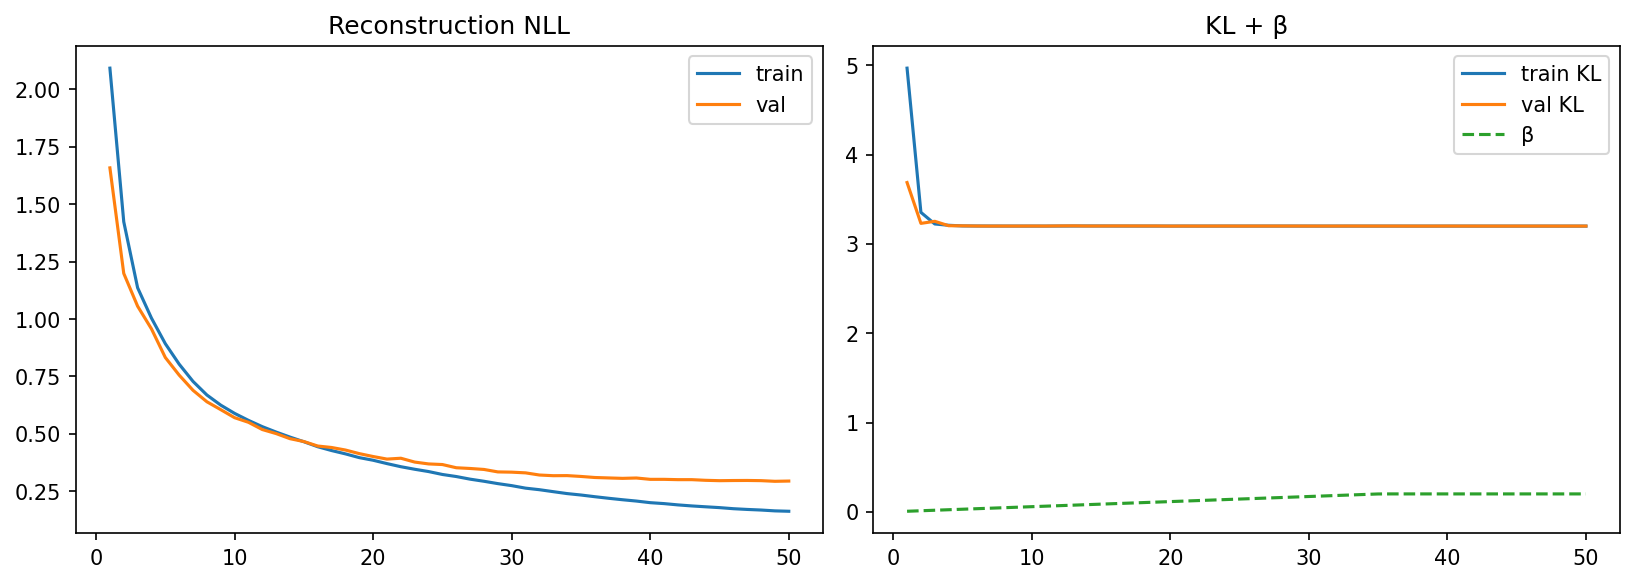

unconditional.png OK


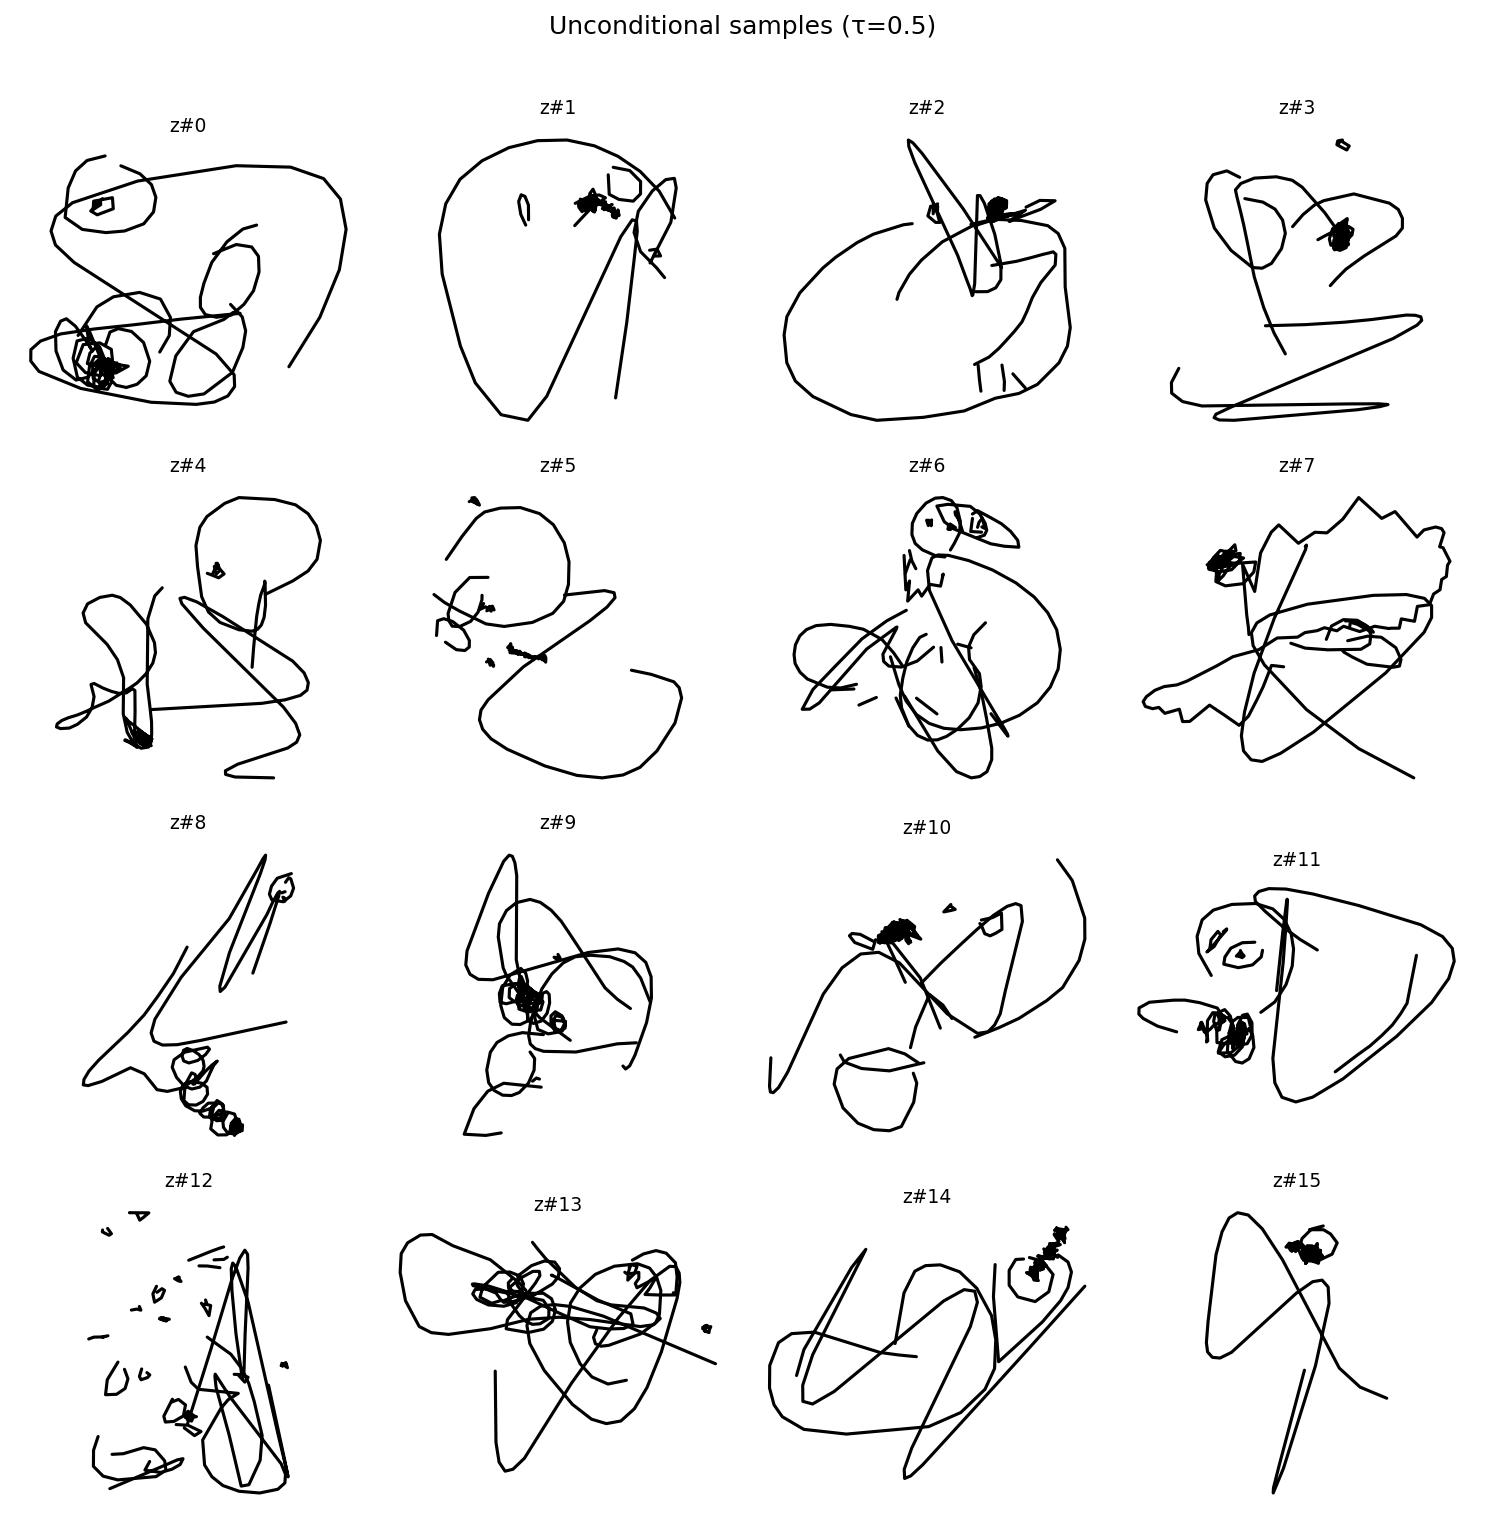

reconstructions.png OK


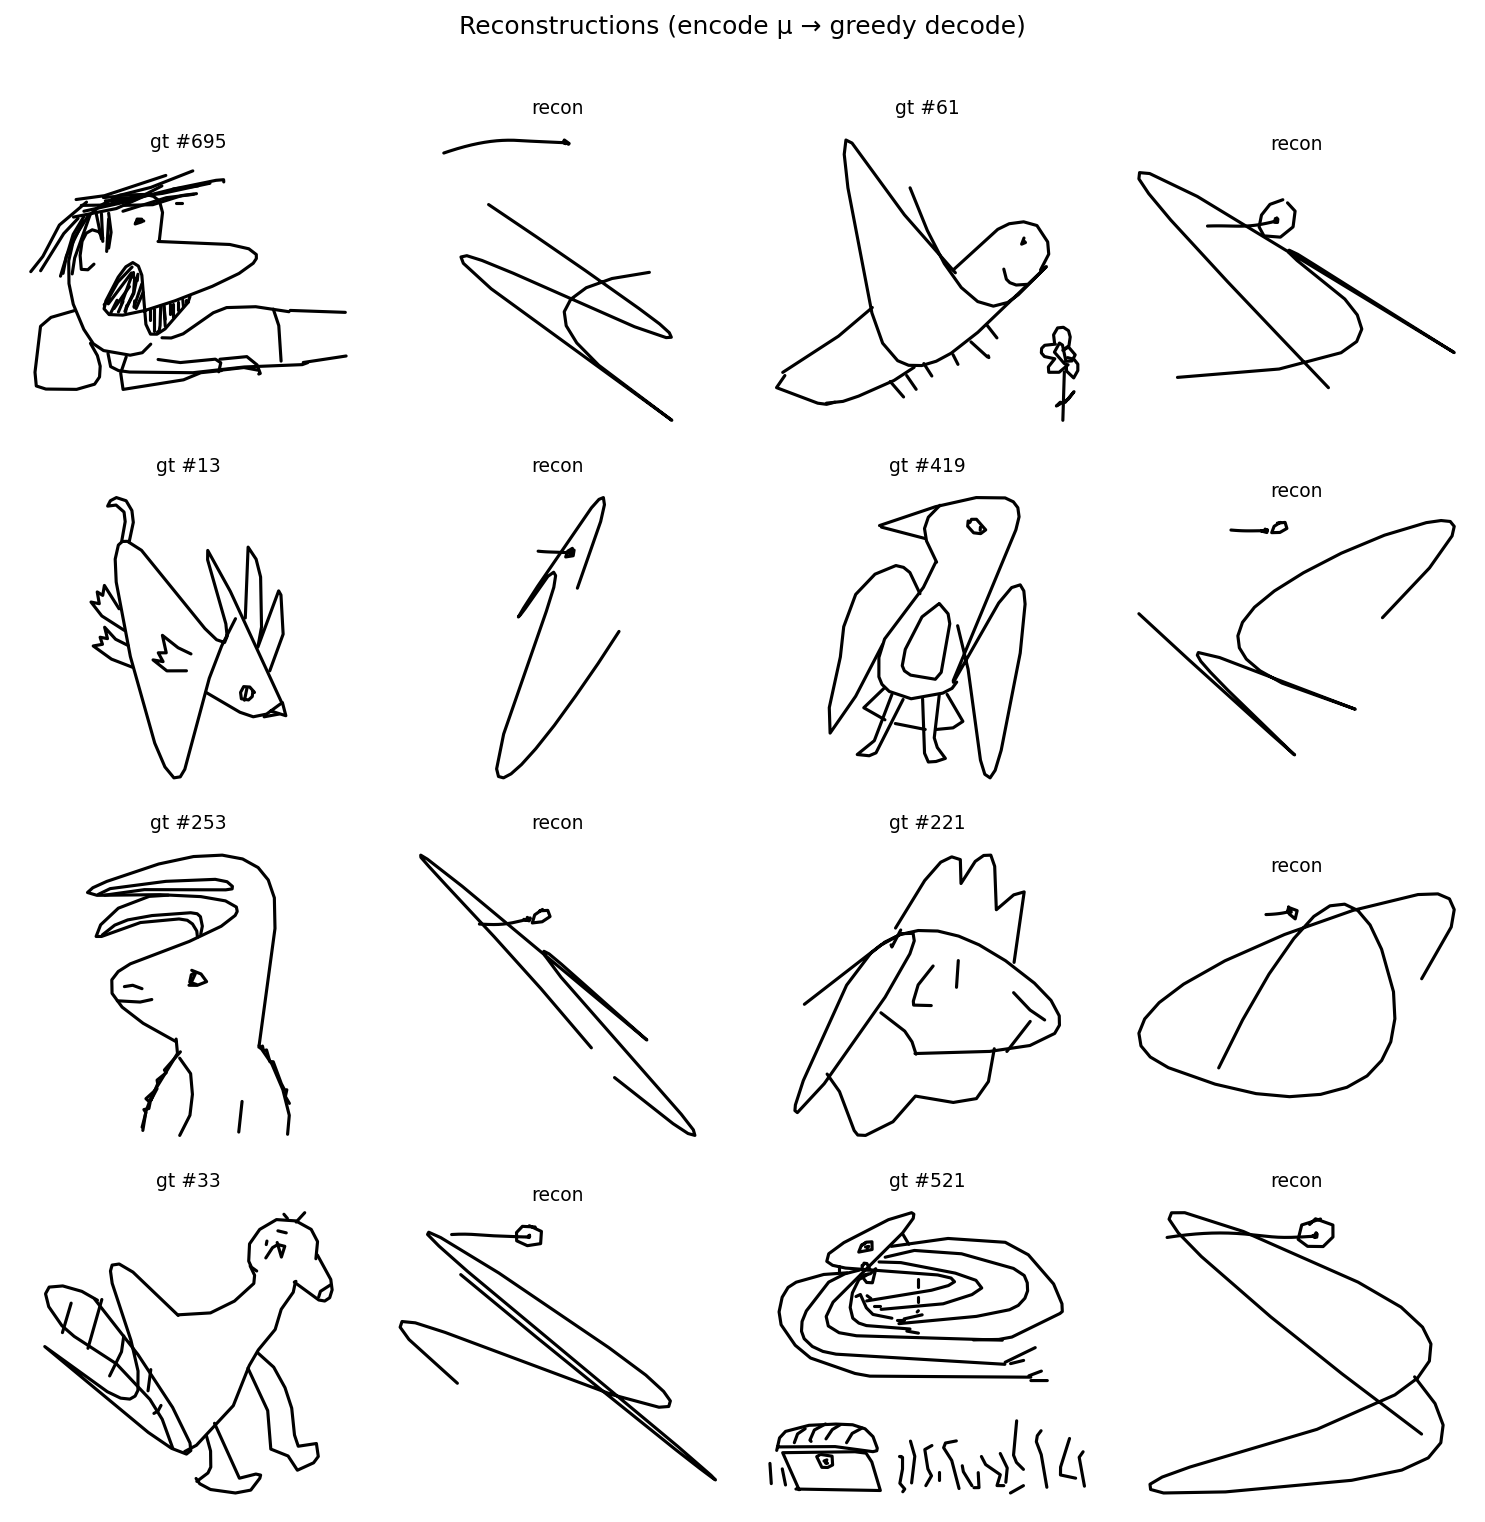

completion.png OK


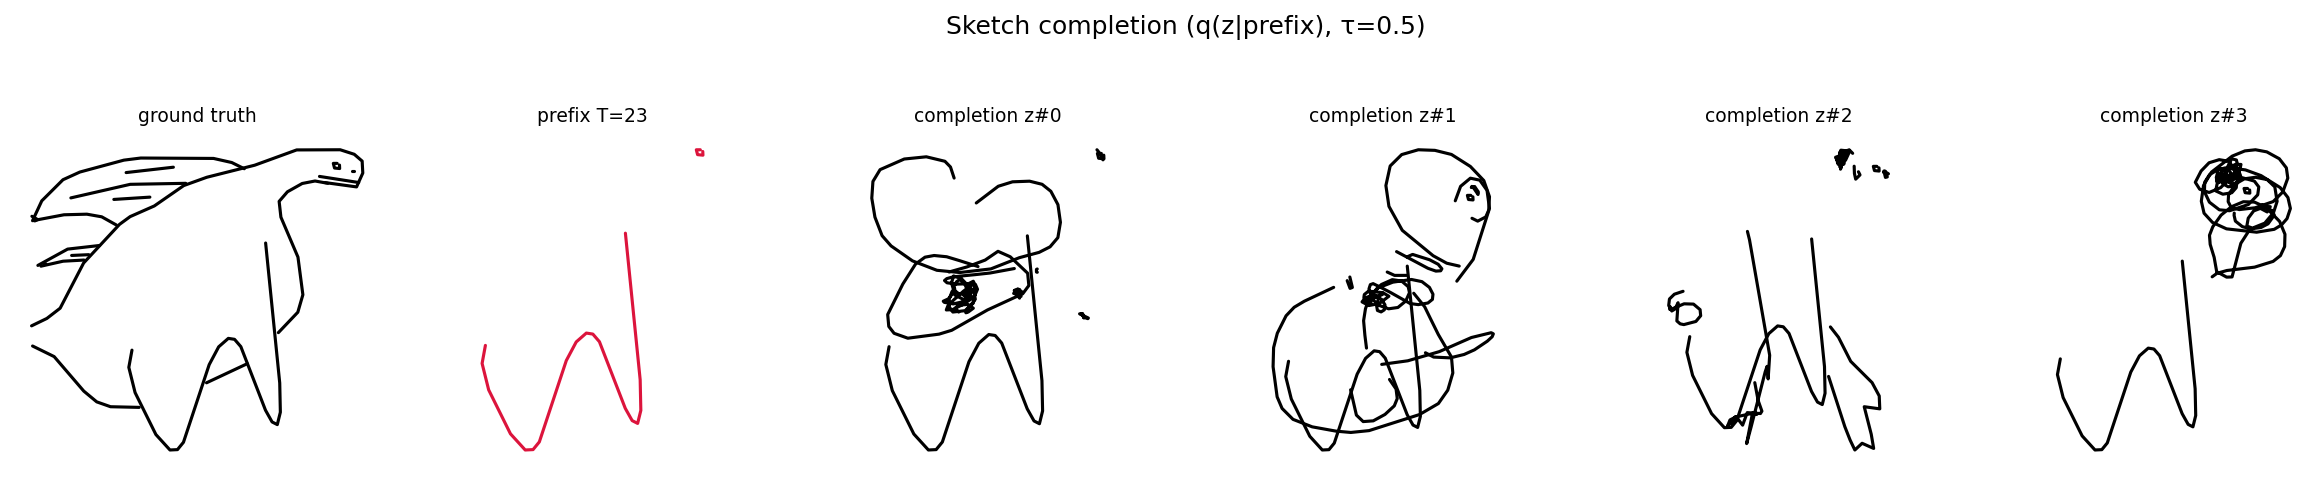

In [8]:
for name in ("curves.png", "unconditional.png", "reconstructions.png", "completion.png"):
    path = EVAL / name
    print(name, "OK" if path.exists() else "(pendiente)")
    if path.exists():
        display(Image(filename=str(path)))
